In [64]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4) (2).zip


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [66]:
import zipfile
import os
with zipfile.ZipFile('archive (4).zip', 'r') as zip_ref:
  \
    zip_ref.extractall('.')
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [67]:
df.shape

(1025, 14)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [69]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [70]:
df['target'].value_counts()

,count
target,
1,526
0,499


In [71]:
df.duplicated().sum()

np.int64(723)

In [72]:
df = df.drop_duplicates()
df.shape

(302, 14)

In [73]:
df['target'].value_counts()

,count
target,
1,164
0,138


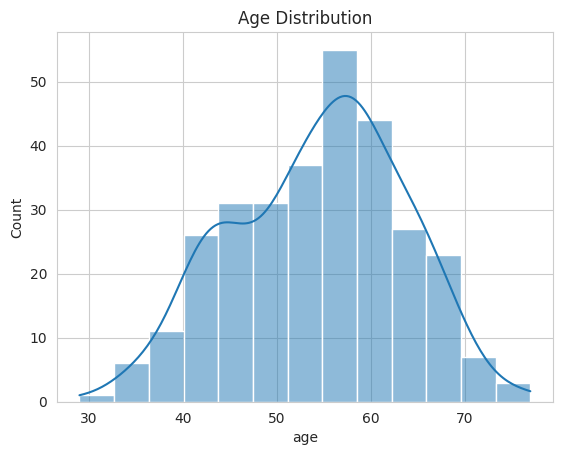

In [74]:
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

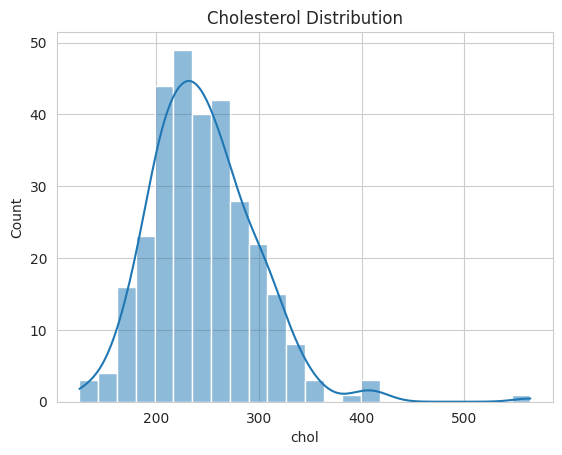

In [75]:
sns.histplot(df['chol'], kde=True)
plt.title('Cholesterol Distribution')
plt.show()

In [76]:
print(df['chol'].mean())
print(df['chol'].median())

246.5
240.5


In [77]:
df.groupby('target')['chol'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,138.0,251.086957,49.454614,131.0,217.25,249.0,283.00,409.0
1,164.0,242.640244,53.456580,126.0,208.75,234.5,267.25,564.0


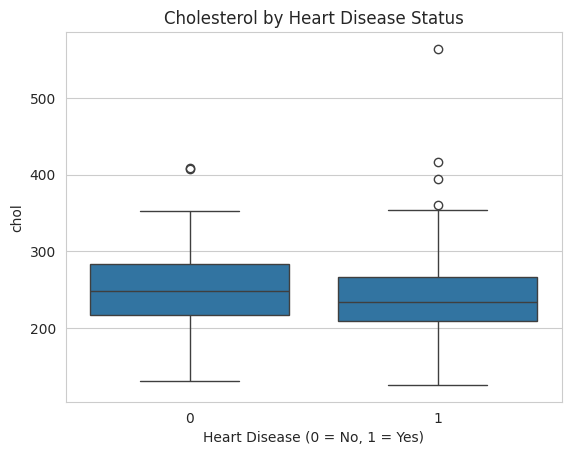

In [78]:
sns.boxplot(x='target', y='chol', data=df)
plt.title('Cholesterol by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.show()

In [79]:
df.groupby('target')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,138.0,56.601449,7.962082,35.0,52.00,58.0,62.0,77.0
1,164.0,52.585366,9.511957,29.0,44.75,52.0,59.0,76.0


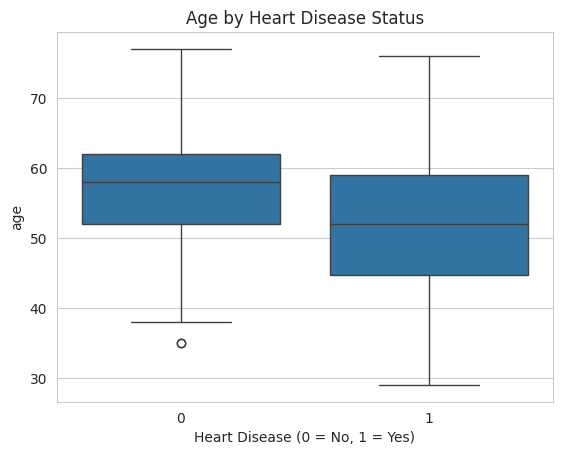

In [80]:
sns.boxplot(x='target', y='age', data=df)
plt.title('Age by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.show()

In [81]:
df.groupby('target')['thalach'].mean()

,thalach
target,
0,139.101449
1,158.378049


In [82]:
df.groupby('target')['cp'].value_counts()


target  cp
0       0     104
        2      18
        1       9
        3       7
1       2      68
        1      41
        0      39
        3      16
Name: count, dtype: int64

In [83]:
df['disease_status'] = df['target'].map({0: 'Disease', 1: 'No Disease'})

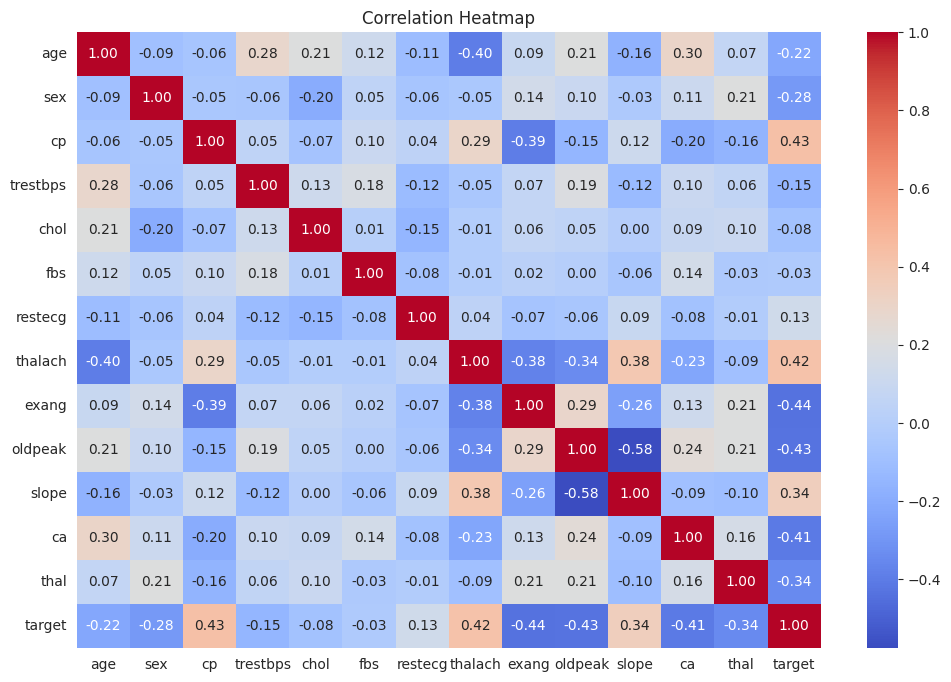

In [84]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In this project, I performed basic exploratory data analysis on a heart disease dataset. The dataset originally had 1025 rows, but checking for duplicates revealed that 723 of them were repeats. After removing duplicates, 302 unique patients remained — 164 with heart disease and 138 without.

There were no missing values in this dataset, so duplicate removal was the main cleaning step needed.

Age followed a roughly normal distribution, with most patients falling between 50 and 65 years old, and no patients under 30. Cholesterol, on the other hand, was right-skewed — most values clustered between 200 and 300, but a few outliers reached as high as 400-560, which pulled the mean slightly above the median.

The most interesting finding involved the target column. The dataset's documentation stated 0 = no disease and 1 = disease, but comparing groups on medically established variables like thalach (maximum heart rate achieved) and cp (chest pain type) showed the encoding was actually reversed — patients with target=0 were the ones with heart disease. This turned out to be a known issue with this particular dataset, and verifying it against known medical patterns rather than trusting the documentation was an important step in the analysis.

The correlation heatmap showed that cp, thalach, exang, oldpeak, and ca had the strongest relationships with heart disease. Cholesterol's correlation was surprisingly weak (around -0.08), which was unexpected given how often cholesterol is cited as a major risk factor. In this dataset, cholesterol alone was not a strong predictor.

In [85]:
import sklearn
print(sklearn.__version__)

1.6.1


In [86]:
X = df.drop(columns=['target', 'disease_status'])
y = df['target']

In [87]:
print(X.shape)
print(y.shape)

(302, 13)
(302,)


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(241, 13)
(61, 13)


In [89]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [90]:
y_pred = model.predict(X_test)

In [91]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.79


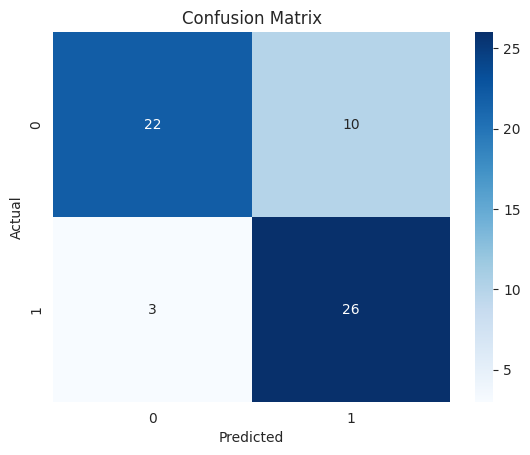

In [92]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [93]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.69      0.77        32
           1       0.72      0.90      0.80        29

    accuracy                           0.79        61
   macro avg       0.80      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



As an extension, I trained a Logistic Regression model to predict heart disease from the remaining features. After splitting the data 80/20 into training and test sets, the model reached 79% accuracy on unseen data. Looking closer with a confusion matrix and classification report showed a more nuanced picture: the model correctly identified 90% of healthy patients but only 69% of patients who actually had heart disease, missing 10 out of 32 disease cases. This highlights that accuracy alone doesn't tell the full story — for a health-related task, the recall on the disease class matters more, since a missed diagnosis is more costly than a false alarm. With a larger dataset or additional feature engineering, this recall could likely be improved.